# Background

The dataset is obtained from kaggle: Online Payments Fraud Detection Dataset (Following the same license CC BY-NC-SA 4.0 https://creativecommons.org/licenses/by-nc-sa/4.0/ as the author)
https://www.kaggle.com/datasets/rupakroy/online-payments-fraud-detection-dataset/data



The dataset refers to the online payments for fraud detection with labeled fraud transaction. We expect to train a machine learning model that could help us to identify fraud transaction when we input new transaction records.

**Dataset Columns:**

- step: numeric - represents a unit of time where 1 step equals 1 hour
- type: text - type of online transaction
- amount: numeric - the amount of the transaction
- nameOrig: alphanumeric - customer starting the transaction
- oldbalanceOrg: numeric - balance before the transaction
- newbalanceOrig: numeric - balance after the transaction
- nameDest: alphanumeric - recipient
- oldbalanceDest: numeric - initial balance of recipient before the transaction
- newbalanceDest: numeric - the new balance of recipient after the transaction
- isFraud: binary - fraud transaction (Yes = 1, No = 0)

---

# Data collection & sampling

We sampled the raw data due to too long computation time. The output "*_sampled.csv" will be used for data analysis and machine learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
csv_file = 'PS_20174392719_1491204439457_log.csv'
folder_path = 'dataset/'
df = pd.read_csv(folder_path + csv_file)

In [2]:
display(df)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0


**Column "isFraud" is the label of the fraud transaction (Yes = 1, No = 0).**

In [3]:
display(df['isFraud'].value_counts())

isFraud
0    6354407
1       8213
Name: count, dtype: int64

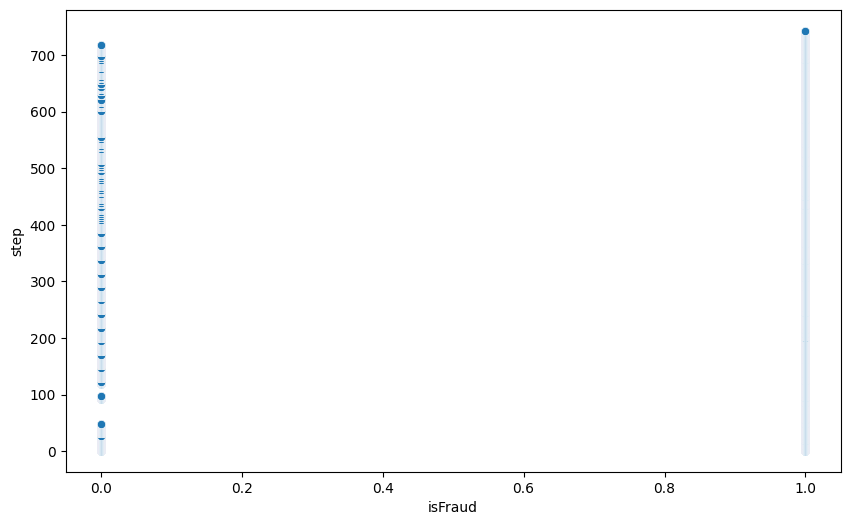

In [4]:
# plot step vs isFraud
plt.figure(figsize=(10, 6))
sns.scatterplot(x='isFraud', y='step', data=df)
plt.xlabel('isFraud')
plt.ylabel('step')
plt.show()

In [5]:
# The original dataset is too large, so we will sample a smaller subset
# Randomly sample n rows from dataframe
df_select = df.sample(n=300000)
display(df_select)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
4014498,299,PAYMENT,327.38,C820540407,93613.14,93285.77,M1795690028,0.00,0.00,0,0
595581,33,CASH_OUT,29549.94,C2063115402,61722.00,32172.06,C706562936,1051115.71,1080665.66,0,0
576209,26,CASH_IN,67774.85,C1858151422,5638612.37,5706387.22,C2130699331,2348093.80,2280318.95,0,0
4974523,352,CASH_IN,32970.04,C1260976755,688805.52,721775.56,C316006995,469007.19,436037.16,0,0
4289510,307,CASH_OUT,242025.04,C1551032077,0.00,0.00,C1295366695,501533.76,743558.80,0,0
...,...,...,...,...,...,...,...,...,...,...,...
4329031,308,CASH_IN,130267.22,C1125834452,173.00,130440.22,C1708070258,3752551.32,3622284.10,0,0
5271293,372,CASH_IN,334706.40,C666254893,30191.00,364897.40,C511173862,0.00,0.00,0,0
2229940,186,CASH_OUT,144170.04,C159965919,0.00,0.00,C1090023811,460436.34,604606.38,0,0
1064072,119,PAYMENT,6631.83,C1249839041,4243.00,0.00,M971672117,0.00,0.00,0,0


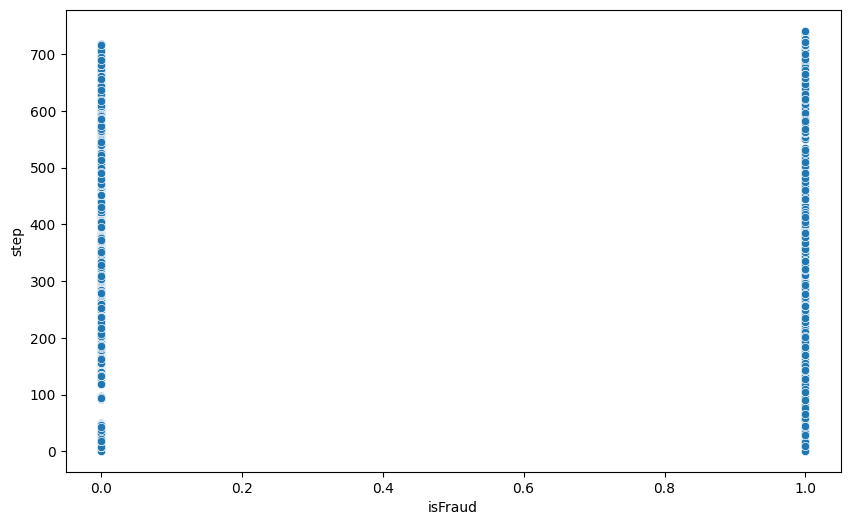

In [6]:
# plot step vs isFraud
plt.figure(figsize=(10, 6))
sns.scatterplot(x='isFraud', y='step', data=df_select)
plt.xlabel('isFraud')
plt.ylabel('step')
plt.show()

In [10]:
# save the sampled df to a new CSV file

df_select.to_csv(folder_path + 'PS_20174392719_1491204439457_log_sampled.csv', index=False)
print("Sampled dataset saved to folder:", folder_path)

Sampled dataset saved to folder: dataset/


---

# 1. Exploratory Data Analysis (EDA)

**Data Preprocessing**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
csv_file = 'PS_20174392719_1491204439457_log_sampled.csv'
folder_path = 'dataset/'
df = pd.read_csv(folder_path + csv_file)
display(df)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,356,CASH_OUT,170752.42,C99773016,117.00,0.00,C401333024,2652774.52,2823526.94,0,0
1,154,CASH_IN,92448.16,C821248515,4929958.34,5022406.50,C1649389360,5299090.14,5206641.98,0,0
2,226,CASH_IN,89140.67,C568942643,7114231.99,7203372.66,C1579653138,253598.78,164458.11,0,0
3,251,PAYMENT,22241.99,C1819571258,14925.00,0.00,M1286535655,0.00,0.00,0,0
4,397,CASH_OUT,19811.19,C1321886710,0.00,0.00,C1555620594,488856.40,508667.60,0,0
...,...,...,...,...,...,...,...,...,...,...,...
299995,376,CASH_OUT,112307.78,C1731371962,0.00,0.00,C1346090632,377440.91,489748.69,0,0
299996,138,CASH_OUT,326600.56,C1950450478,7911.00,0.00,C208393407,0.00,326600.56,0,0
299997,347,DEBIT,107.16,C1155235666,5663.00,5555.84,C1068659199,1716927.05,1717034.21,0,0
299998,351,PAYMENT,30838.22,C1902420663,0.00,0.00,M923596278,0.00,0.00,0,0


In [3]:
# display the data types
print("Data types:")
print(df.dtypes)

Data types:
step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object


The dataset is very clean, without any missing value:

In [4]:
# search for missing values
print("Missing values count:")
print(df.isnull().sum())

Missing values count:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


In [5]:
# search for unique values in each column
print("Unique values in each column:")
print(df.nunique())

Unique values in each column:
step                 559
type                   5
amount            296803
nameOrig          299980
oldbalanceOrg     138159
newbalanceOrig    129691
nameDest          247913
oldbalanceDest    172454
newbalanceDest    184011
isFraud                2
isFlaggedFraud         1
dtype: int64


In [6]:
# statistics of dataset
print("Statistics of dataset:")
df.describe()

Statistics of dataset:


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,300000.000000,3.000000e+05,3.000000e+05,3.000000e+05,3.000000e+05,3.000000e+05,300000.000000,300000.0
mean,243.429790,1.813279e+05,8.349397e+05,8.560599e+05,1.099667e+06,1.224785e+06,0.001367,0.0
std,142.421448,6.438801e+05,2.894545e+06,2.929898e+06,3.402528e+06,3.699119e+06,0.036943,0.0
min,1.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0
25%,155.000000,1.334791e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0
50%,239.000000,7.509661e+04,1.424130e+04,0.000000e+00,1.334446e+05,2.148326e+05,0.000000,0.0
75%,334.000000,2.090544e+05,1.077632e+05,1.451151e+05,9.426456e+05,1.111774e+06,0.000000,0.0
max,741.000000,6.676127e+07,4.567455e+07,3.567455e+07,3.560159e+08,3.561793e+08,1.000000,0.0


Drop the Name columns which are not useful. 

In [7]:
# drop the columns which are not useful
df.drop(columns=['nameOrig', 'nameDest', 'isFlaggedFraud'], inplace=True)
display(df)

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
0,356,CASH_OUT,170752.42,117.00,0.00,2652774.52,2823526.94,0
1,154,CASH_IN,92448.16,4929958.34,5022406.50,5299090.14,5206641.98,0
2,226,CASH_IN,89140.67,7114231.99,7203372.66,253598.78,164458.11,0
3,251,PAYMENT,22241.99,14925.00,0.00,0.00,0.00,0
4,397,CASH_OUT,19811.19,0.00,0.00,488856.40,508667.60,0
...,...,...,...,...,...,...,...,...
299995,376,CASH_OUT,112307.78,0.00,0.00,377440.91,489748.69,0
299996,138,CASH_OUT,326600.56,7911.00,0.00,0.00,326600.56,0
299997,347,DEBIT,107.16,5663.00,5555.84,1716927.05,1717034.21,0
299998,351,PAYMENT,30838.22,0.00,0.00,0.00,0.00,0


Rename column name for easier reading.

In [8]:
# rename column name for easier reading
df = df.rename(columns={'type': 'transactionType',
                        'amount': 'transactionAmt',
                        'oldbalanceOrg': 'balanceBefore',
                        'newbalanceOrig': 'balanceAfter',
                        'oldbalanceDest': 'destBalanceBefore',
                        'newbalanceDest': 'destBalanceAfter'})
df.head(5)

,step,transactionType,transactionAmt,balanceBefore,balanceAfter,destBalanceBefore,destBalanceAfter,isFraud
0,356,CASH_OUT,170752.42,117.00,0.00,2652774.52,2823526.94,0
1,154,CASH_IN,92448.16,4929958.34,5022406.50,5299090.14,5206641.98,0
2,226,CASH_IN,89140.67,7114231.99,7203372.66,253598.78,164458.11,0
3,251,PAYMENT,22241.99,14925.00,0.00,0.00,0.00,0
4,397,CASH_OUT,19811.19,0.00,0.00,488856.40,508667.60,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 8 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   step               300000 non-null  int64  
 1   transactionType    300000 non-null  object 
 2   transactionAmt     300000 non-null  float64
 3   balanceBefore      300000 non-null  float64
 4   balanceAfter       300000 non-null  float64
 5   destBalanceBefore  300000 non-null  float64
 6   destBalanceAfter   300000 non-null  float64
 7   isFraud            300000 non-null  int64  
dtypes: float64(5), int64(2), object(1)
memory usage: 18.3+ MB


---

**Data Analysis**

In [10]:
# show the count of fraud and non-fraud transactions
df['isFraud'].value_counts()

isFraud
0    299590
1       410
Name: count, dtype: int64

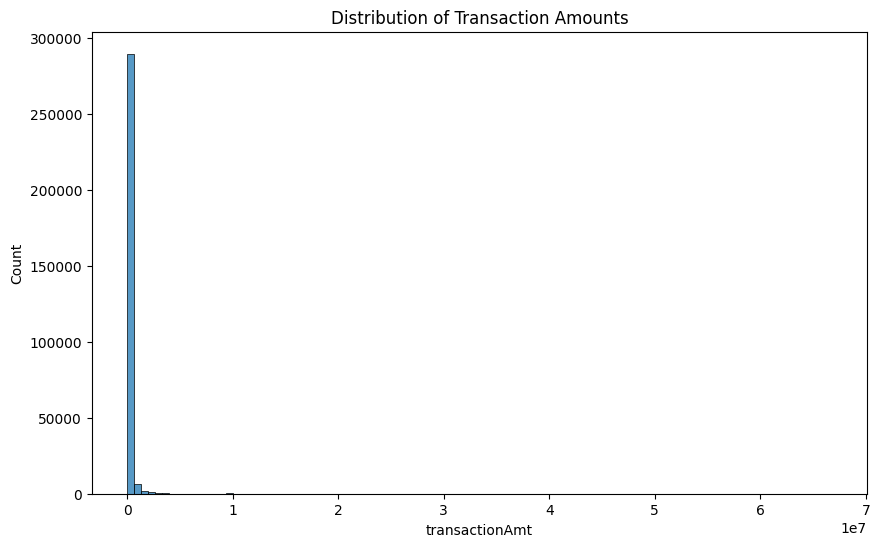

In [11]:
# Plotting the distribution of transaction amounts
plt.figure(figsize=(10, 6))
sns.histplot(x='transactionAmt', data=df, bins=100)
plt.title('Distribution of Transaction Amounts')
plt.show()

From the below bar chart, only CASH_OUT and TRANSFER contains fraud transactions. The orange color is barely visible due to the count is relatively too small.

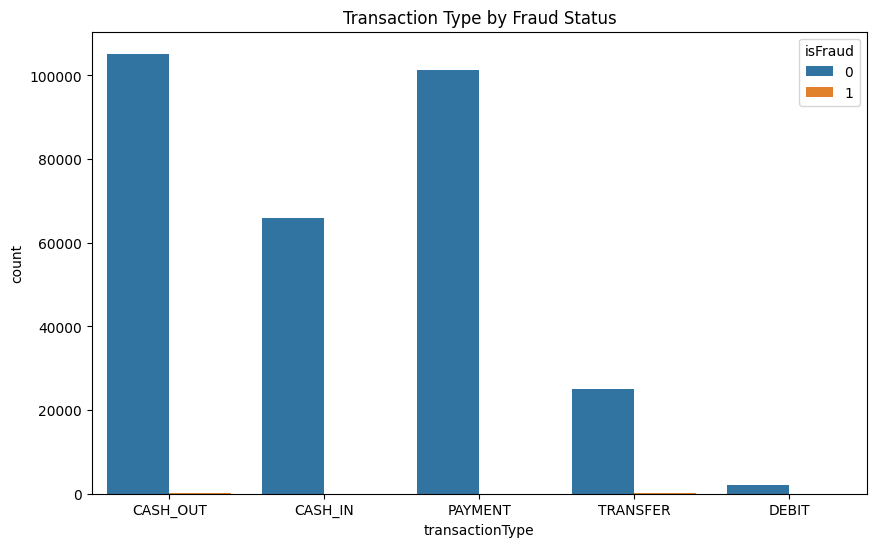

In [12]:
# plot transactionType
plt.figure(figsize=(10, 6))
sns.countplot(x='transactionType', hue='isFraud', data=df)
plt.title('Transaction Type by Fraud Status')
plt.show()

Fraud transaction has higher transaction amount than normal.

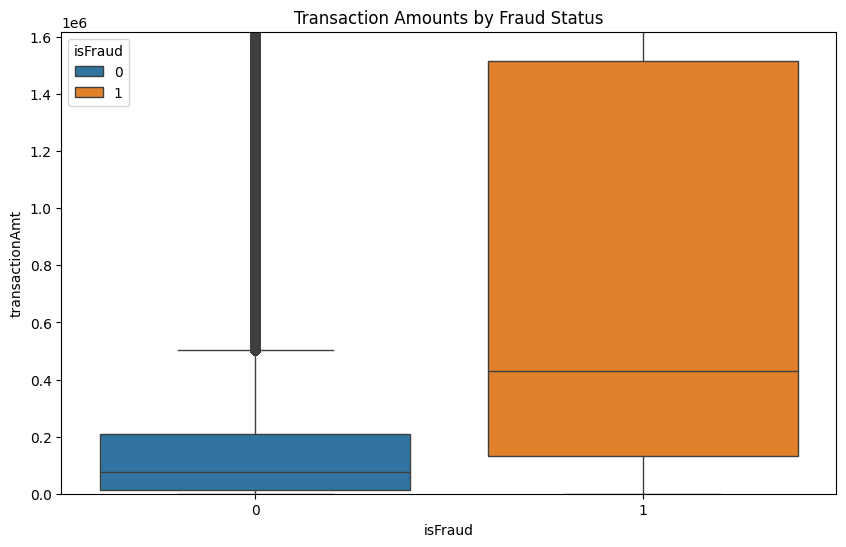

In [13]:
# box plot for transaction amounts by fraud status
plt.figure(figsize=(10, 6))
sns.boxplot(x='isFraud', y='transactionAmt', data=df, hue='isFraud')
plt.title('Transaction Amounts by Fraud Status')
plt.ylim(0, df['transactionAmt'].quantile(0.99))
plt.show()

The below boxplot clearly shows only CASH_OUT and TRANSFER contains fraud transactions.

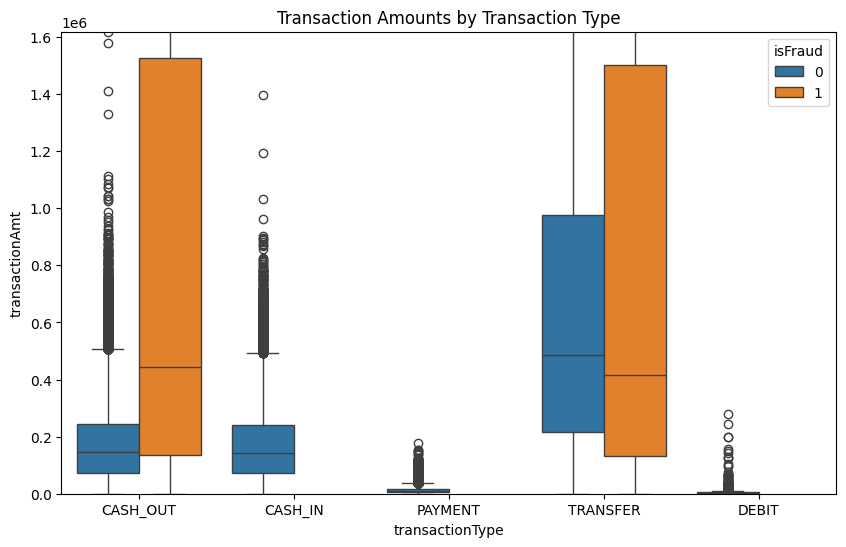

In [14]:
# Plotting the distribution of transaction amounts of transaction types
plt.figure(figsize=(10, 6))
sns.boxplot(x='transactionType', y='transactionAmt', data=df, hue='isFraud')
plt.title('Transaction Amounts by Transaction Type')
plt.ylim(0, df['transactionAmt'].quantile(0.99))
plt.show()

Account balance after fraud transaction significantly decrease.

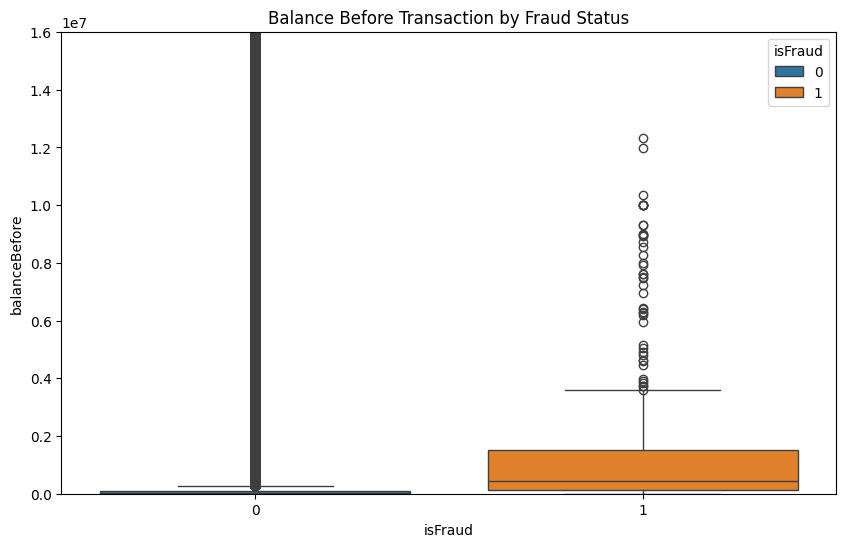

In [15]:
# plot balanceBefore transactions
plt.figure(figsize=(10, 6))
sns.boxplot(x='isFraud', y='balanceBefore', data=df, hue='isFraud')
plt.title('Balance Before Transaction by Fraud Status')
plt.ylim(0, df['balanceBefore'].quantile(0.99))
plt.show()

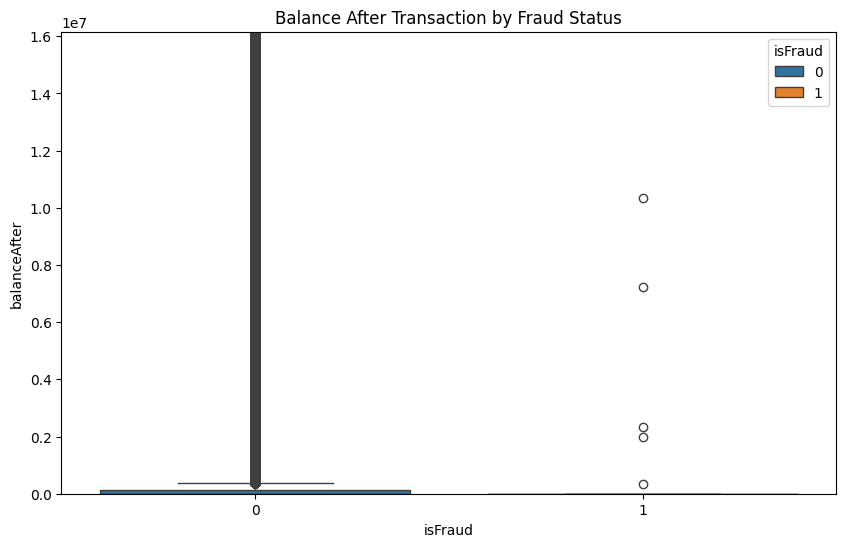

In [16]:
# plot balanceAfter transactions
plt.figure(figsize=(10, 6))
sns.boxplot(x='isFraud', y='balanceAfter', data=df, hue='isFraud')
plt.title('Balance After Transaction by Fraud Status')
plt.ylim(0, df['balanceAfter'].quantile(0.99))
plt.show()

Recipient Account balance after fraud transaction significantly increase.

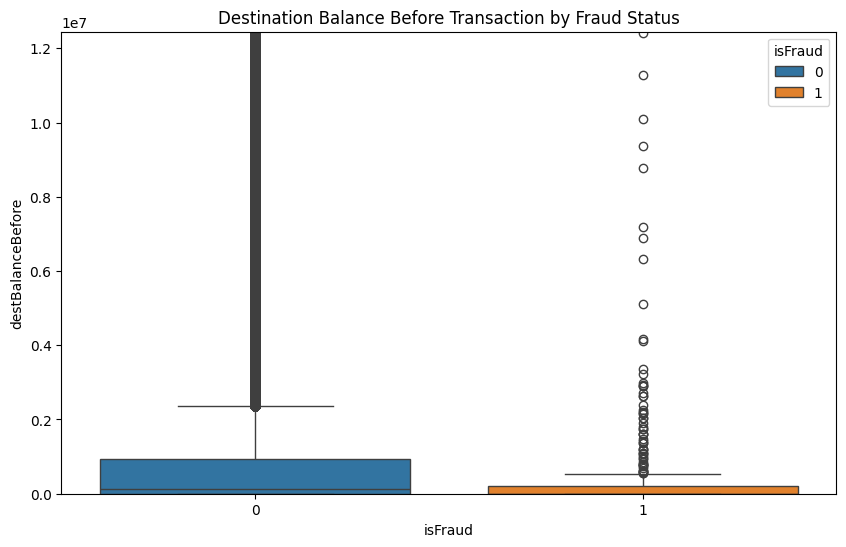

In [17]:
# plot destBalanceBefore transactions
plt.figure(figsize=(10, 6))
sns.boxplot(x='isFraud', y='destBalanceBefore', data=df, hue='isFraud')
plt.title('Destination Balance Before Transaction by Fraud Status')
plt.ylim(0, df['destBalanceBefore'].quantile(0.99))
plt.show()

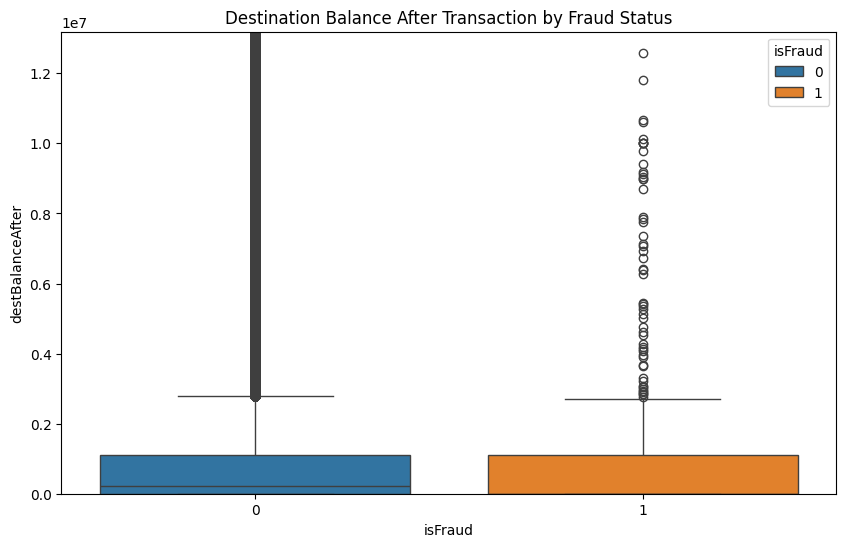

In [18]:
# plot destBalanceAfter transactions
plt.figure(figsize=(10, 6))
sns.boxplot(x='isFraud', y='destBalanceAfter', data=df, hue='isFraud')
plt.title('Destination Balance After Transaction by Fraud Status')
plt.ylim(0, df['destBalanceAfter'].quantile(0.99))
plt.show()

Account balance after fraud transaction significantly decrease or goes to zero. While normal transactions remain similar account balance in general.

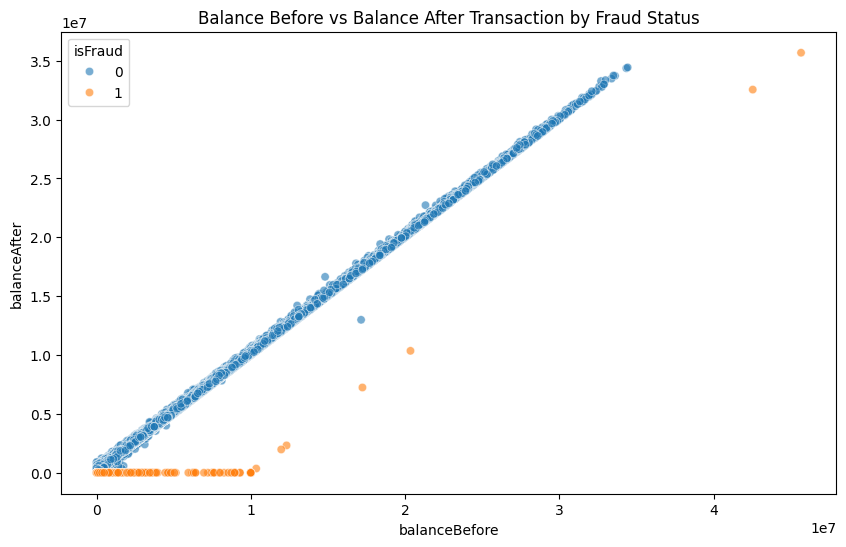

In [19]:
# plot balance after transaction vs balance before transaction with hue by isFraud
df_sorted = df.sort_values('isFraud') # Sort by isFraud for better visualization (on top)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='balanceBefore', y='balanceAfter', data=df_sorted, hue='isFraud', alpha=0.6)
plt.title('Balance Before vs Balance After Transaction by Fraud Status')
plt.show()

Recipient account balance before fraud transaction generally less than normal.

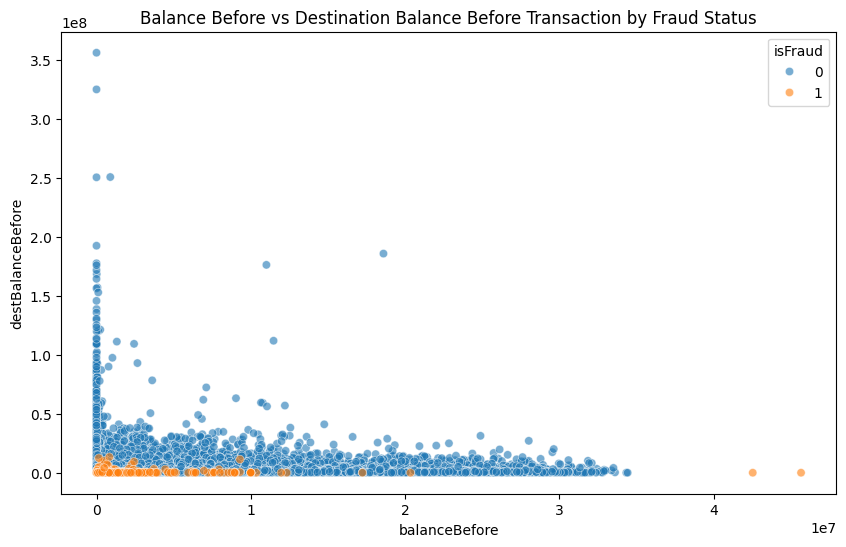

In [20]:
# plot destination balance before transaction vs balance before transaction with hue by isFraud
plt.figure(figsize=(10, 6))
sns.scatterplot(x='balanceBefore', y='destBalanceBefore', data=df_sorted, hue='isFraud', alpha=0.6)
plt.title('Balance Before vs Destination Balance Before Transaction by Fraud Status')
plt.show()

Here below shows the "step" column does not have any relationship to the transaction amount with different fraud status, we assume this feature is not useful for machine learning purpose.

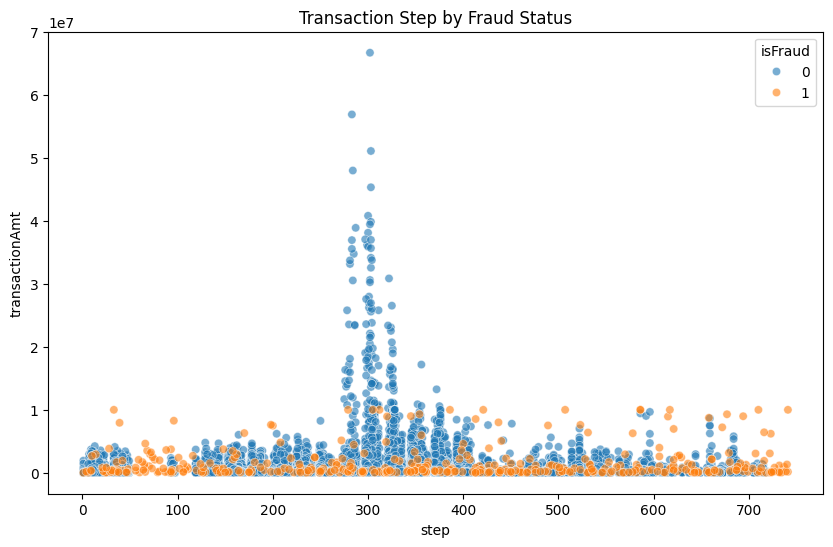

In [21]:
# plot step column with hue
plt.figure(figsize=(10, 6))
sns.scatterplot(x='step', y='transactionAmt',data=df_sorted, hue='isFraud', alpha=0.6)
plt.title('Transaction Step by Fraud Status')
plt.show()

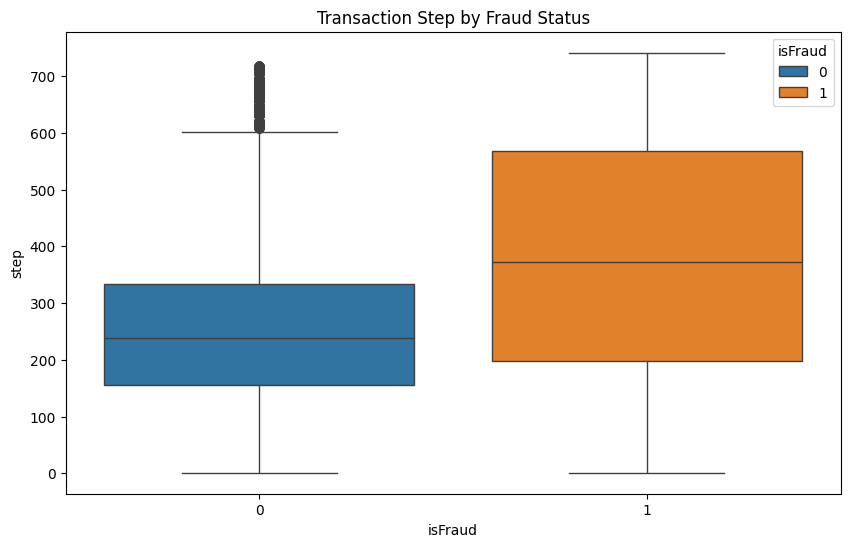

In [22]:
# plot step of fraud transactions
plt.figure(figsize=(10, 6))
sns.boxplot(x='isFraud', y='step', data=df, hue='isFraud')
plt.title('Transaction Step by Fraud Status')
plt.show()

In [23]:
df_fraud = df[df['isFraud'] == 1]

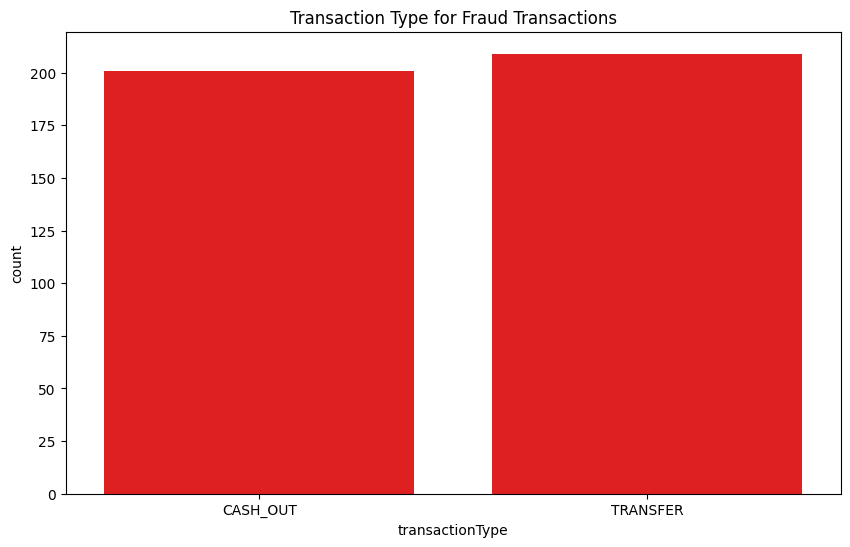

In [24]:
# plot transactionType for isFraud = 1
plt.figure(figsize=(10, 6))
sns.countplot(x='transactionType', data=df_fraud, color='red')
plt.title('Transaction Type for Fraud Transactions')
plt.show()

For Fraud transactions, both transaction types have similar transaction amount.

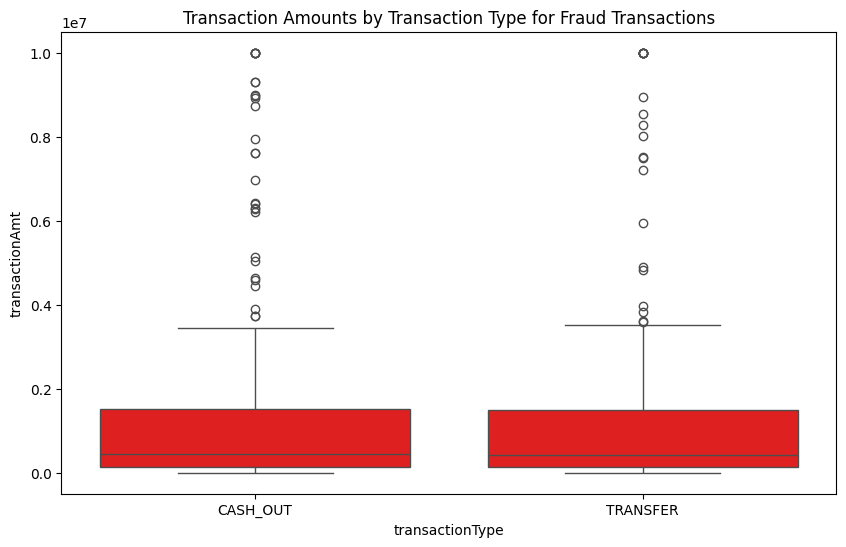

In [25]:
# Plotting the distribution of transaction amounts of transaction types
plt.figure(figsize=(10, 6))
sns.boxplot(x='transactionType', y='transactionAmt', data=df_fraud, color='red')
plt.title('Transaction Amounts by Transaction Type for Fraud Transactions')
plt.show()

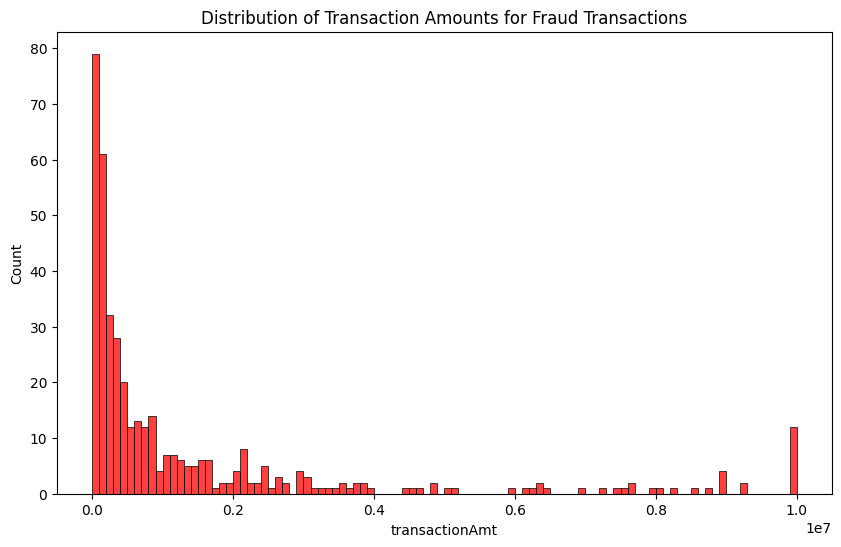

In [26]:
# Plotting the distribution of transaction amounts for fraud transactions
plt.figure(figsize=(10, 6))
sns.histplot(x='transactionAmt', data=df_fraud, bins=100, color='red')
plt.title('Distribution of Transaction Amounts for Fraud Transactions')
plt.show()

Account balance after fraud transaction significantly decrease.

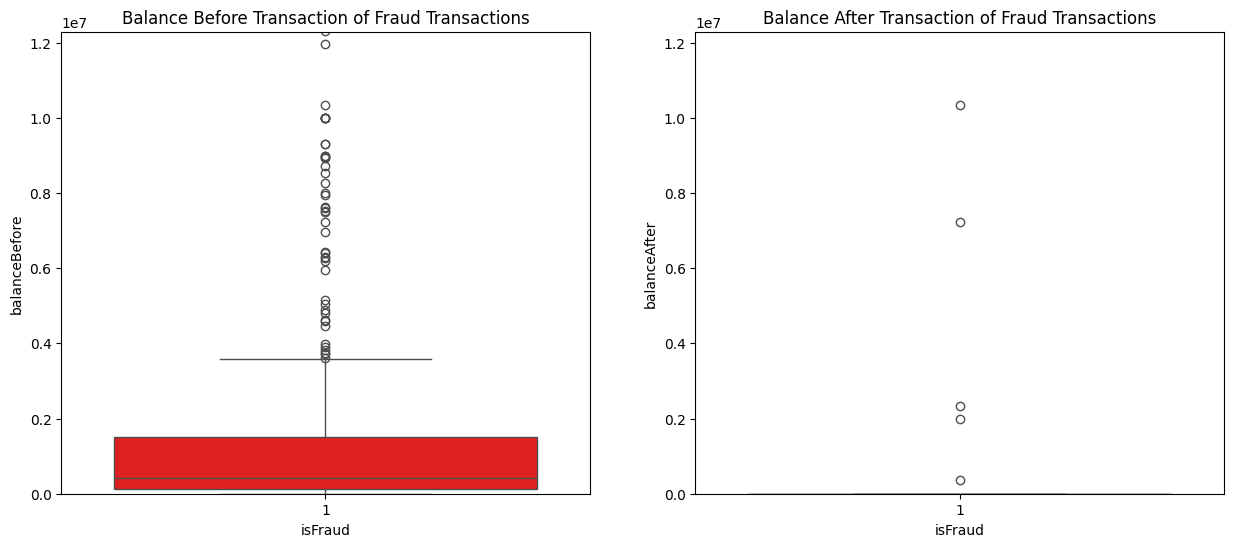

In [27]:
# 1x2 grid for balanceBefore and balanceAfter of Fraud Transactions
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.boxplot(x='isFraud', y='balanceBefore', data=df_fraud, color='red', ax=axes[0])
sns.boxplot(x='isFraud', y='balanceAfter', data=df_fraud, color='red', ax=axes[1])
axes[0].set_title('Balance Before Transaction of Fraud Transactions')
axes[1].set_title('Balance After Transaction of Fraud Transactions')
axes[0].set_ylim(0, df_fraud['balanceBefore'].quantile(0.99))
axes[1].set_ylim(0, df_fraud['balanceBefore'].quantile(0.99))
plt.show()

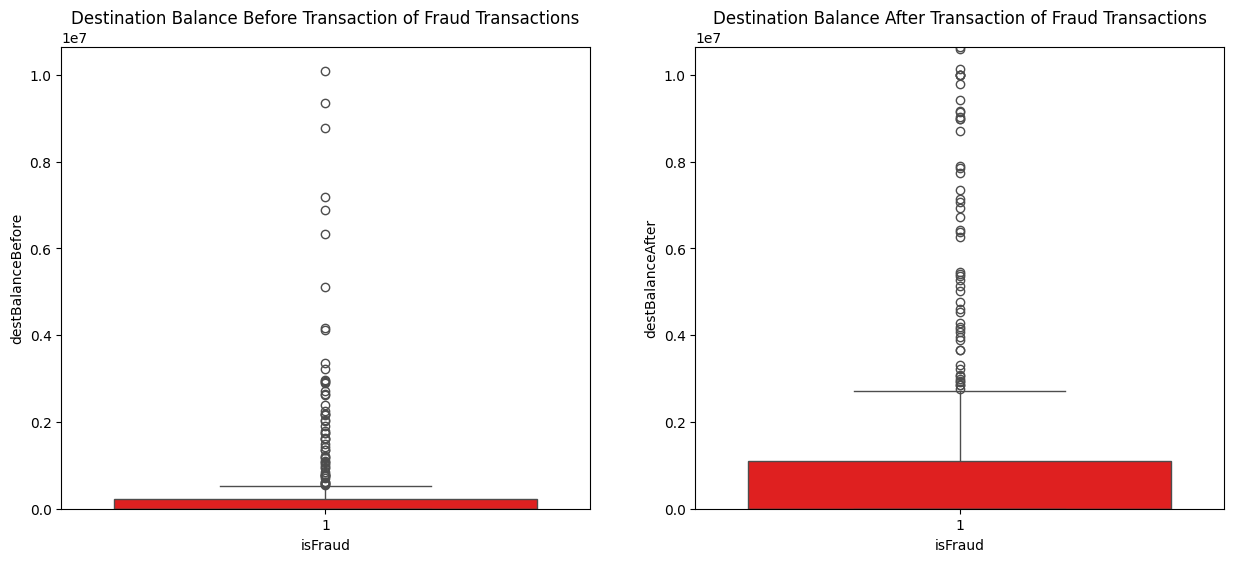

In [28]:
# 1x2 grid for destination balanceBefore and balanceAfter of Fraud Transactions
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.boxplot(x='isFraud', y='destBalanceBefore', data=df_fraud, color='red', ax=axes[0])
sns.boxplot(x='isFraud', y='destBalanceAfter', data=df_fraud, color='red', ax=axes[1])
axes[0].set_title('Destination Balance Before Transaction of Fraud Transactions')
axes[1].set_title('Destination Balance After Transaction of Fraud Transactions')
axes[0].set_ylim(0, df_fraud['destBalanceAfter'].quantile(0.99))
axes[1].set_ylim(0, df_fraud['destBalanceAfter'].quantile(0.99))
plt.show()

---

# 2. Machine Learning

In [30]:
from sklearn.preprocessing import LabelEncoder

# label encoding for transactionType
le = LabelEncoder()
df['transactionType'] = le.fit_transform(df['transactionType'])

display(df)

,step,transactionType,transactionAmt,balanceBefore,balanceAfter,destBalanceBefore,destBalanceAfter,isFraud
0,356,1,170752.42,117.00,0.00,2652774.52,2823526.94,0
1,154,0,92448.16,4929958.34,5022406.50,5299090.14,5206641.98,0
2,226,0,89140.67,7114231.99,7203372.66,253598.78,164458.11,0
3,251,3,22241.99,14925.00,0.00,0.00,0.00,0
4,397,1,19811.19,0.00,0.00,488856.40,508667.60,0
...,...,...,...,...,...,...,...,...
299995,376,1,112307.78,0.00,0.00,377440.91,489748.69,0
299996,138,1,326600.56,7911.00,0.00,0.00,326600.56,0
299997,347,2,107.16,5663.00,5555.84,1716927.05,1717034.21,0
299998,351,3,30838.22,0.00,0.00,0.00,0.00,0


**Feature Selection**

Training data removed 'step' column, and labeled column 'isFraud'

In [31]:
# feature selection
X = df.drop(columns=['step', 'isFraud'])
y = df['isFraud']

print("X:")
print(X.head())
print("y:")
print(y.head())

X:
   transactionType  transactionAmt  balanceBefore  balanceAfter  \
0                1       170752.42         117.00          0.00   
1                0        92448.16     4929958.34    5022406.50   
2                0        89140.67     7114231.99    7203372.66   
3                3        22241.99       14925.00          0.00   
4                1        19811.19           0.00          0.00   

   destBalanceBefore  destBalanceAfter  
0         2652774.52        2823526.94  
1         5299090.14        5206641.98  
2          253598.78         164458.11  
3               0.00              0.00  
4          488856.40         508667.60  
y:
0    0
1    0
2    0
3    0
4    0
Name: isFraud, dtype: int64


**Train 4 different models**
- Logistic Regression
- SVM Classifier
- Random Forest Classifier
- kNN Classifier

In [32]:
from sklearn.model_selection import train_test_split

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [33]:
# Logistic Regression, SVM Classifier, Random Forest Classifier, kNN Classifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [34]:
# Logistic Regression
lr_model = LogisticRegression(solver='liblinear', random_state=42)
lr_model.fit(X_train,y_train)

y_pred_lr = lr_model.predict(X_test)

print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_lr))
print("Logistic Regression Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))
print("Logistic Regression Accuracy Score:", accuracy_score(y_test, y_pred_lr))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     59906
           1       0.73      0.73      0.73        94

    accuracy                           1.00     60000
   macro avg       0.87      0.87      0.87     60000
weighted avg       1.00      1.00      1.00     60000

Logistic Regression Confusion Matrix:
[[59881    25]
 [   25    69]]
Logistic Regression Accuracy Score: 0.9991666666666666


c:\Users\Alvin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\svm\_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [35]:
# Support Vector Machine Classifier
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

print("SVM Classification Report:")
print(classification_report(y_test, y_pred_svm))
print("SVM Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))
print("SVM Accuracy Score:", accuracy_score(y_test, y_pred_svm))

SVM Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     59906
           1       1.00      0.26      0.41        94

    accuracy                           1.00     60000
   macro avg       1.00      0.63      0.70     60000
weighted avg       1.00      1.00      1.00     60000

SVM Confusion Matrix:
[[59906     0]
 [   70    24]]
SVM Accuracy Score: 0.9988333333333334


In [36]:
# Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))
print("Random Forest Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("Random Forest Accuracy Score:", accuracy_score(y_test, y_pred_rf))

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     59906
           1       0.96      0.77      0.85        94

    accuracy                           1.00     60000
   macro avg       0.98      0.88      0.93     60000
weighted avg       1.00      1.00      1.00     60000

Random Forest Confusion Matrix:
[[59903     3]
 [   22    72]]
Random Forest Accuracy Score: 0.9995833333333334


In [37]:
# kNN Classifier
knn_model = KNeighborsClassifier(n_neighbors=3)
knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)

print("kNN Classification Report:")
print(classification_report(y_test, y_pred_knn))
print("kNN Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))
print("kNN Accuracy Score:", accuracy_score(y_test, y_pred_knn))

kNN Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     59906
           1       0.91      0.65      0.76        94

    accuracy                           1.00     60000
   macro avg       0.95      0.82      0.88     60000
weighted avg       1.00      1.00      1.00     60000

kNN Confusion Matrix:
[[59900     6]
 [   33    61]]
kNN Accuracy Score: 0.99935


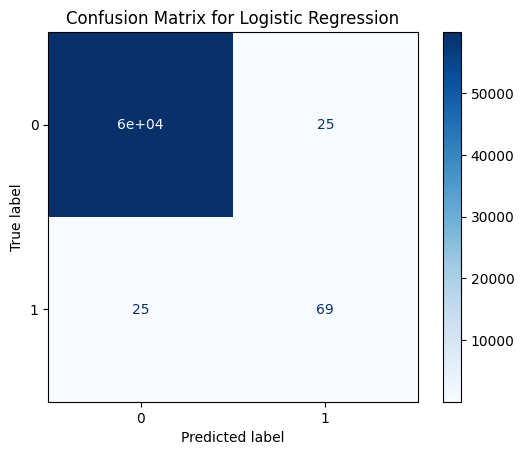

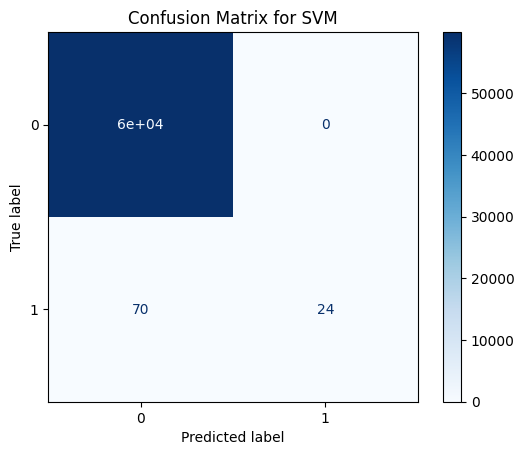

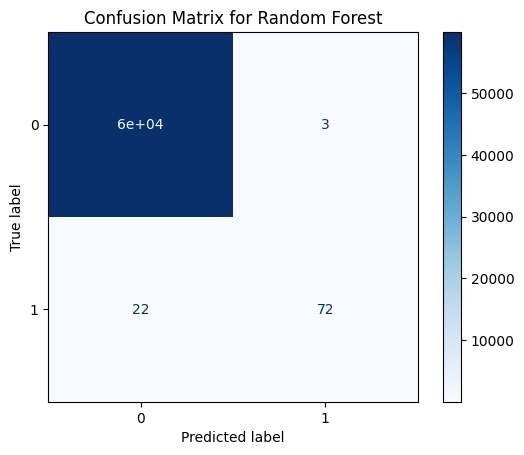

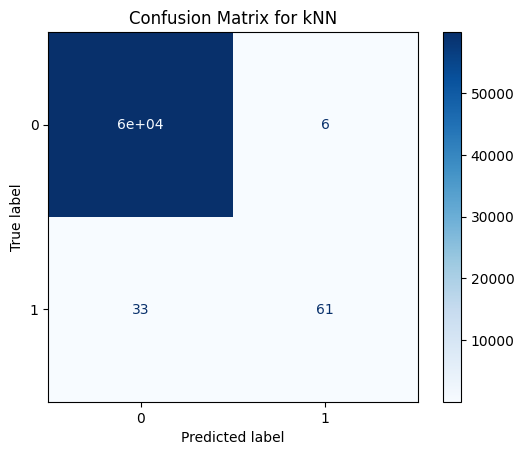

In [38]:
# Display confusion matrices for each model
from sklearn.metrics import ConfusionMatrixDisplay

def display_confusion_matrix(y_test, y_pred, model_name):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix for {model_name}')
    plt.show()

model_names = {'Logistic Regression':'y_pred_lr', 'SVM':'y_pred_svm', 'Random Forest':'y_pred_rf', 'kNN':'y_pred_knn'}

for key, value in model_names.items():
    y_pred = eval(value)
    display_confusion_matrix(y_test, y_pred, key)

Here below show the columns that most inference the raindom forest model prediction:
1. (+0.33) The new balance of recipient after the transaction
2. (+0.31) Balance before the transaction (customer starting the transaction)
3. (+0.19) Transaction Amount

**Feature Importances**

In [39]:
# Display feature importances for Random Forest model
importances = rf_model.feature_importances_
feature_names = X.columns.tolist()
feature_importances = pd.DataFrame({'Feature': feature_names, 'Importance':importances})

# Sort by importance and display the top 5 features
top_features = feature_importances.sort_values(by='Importance', ascending=False).head(5)
print("Random Forest: Top 5 Features and their Importance Scores:")
print(top_features)

Random Forest: Top 5 Features and their Importance Scores:
             Feature  Importance
5   destBalanceAfter    0.327968
2      balanceBefore    0.311612
1     transactionAmt    0.185362
4  destBalanceBefore    0.095629
0    transactionType    0.059614


Logistic Regression coefficients show how each feature changes fraud probability.

1. Positive coef. (+1.2e-04) : Higher feature value = HIGHER fraud probability
2. Negative coef. (-1.86e-04) : Higher feature value = LOWER fraud probability

In [40]:
# Display coefficients for Logistic Regression model
coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': lr_model.coef_[0]})
coefficients = coefficients.sort_values(by='Coefficient', ascending=False)
print("Logistic Regression: Coefficients:")
print(coefficients)

Logistic Regression: Coefficients:
             Feature   Coefficient
2      balanceBefore  1.201411e-04
5   destBalanceAfter  3.285665e-07
0    transactionType -1.697884e-07
4  destBalanceBefore -3.432579e-06
1     transactionAmt -1.198351e-04
3       balanceAfter -1.856034e-04


---

# 3. Result

**The Trade-off Between Recall and Precision**

- High Recall is Important: When the cost of false negatives is very high (eg. medical diagnosis, **fraud detection**)

- High Precision is Important: When the cost of false positives is very high (eg. spam detection, loan approval)

- Balance is Important: A good balance between precision and recall (eg. general classification tasks), use the F1-score

**Ramdom Forest model is the best in this case, with highest Recall Rate: 0.77, highest F1-score: 0.85, Precision: 0.96**

Ramdom Forest model with the highest recall rate able to capture fraud transaction as much as possible.

- High Recall rate: Random Forest, Logistic Regression

- Moderate Recall rate: K-Nearest Neighbors (kNN)

- Poor Recall rate: Support Vector Machine (SVM)



**Save the trained Random Forest model for future use**

In [ ]:
import joblib
import os
# Random Forest Classifier
rf_model_final = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model_final.fit(X, y)

# Save the model by joblib
os.makedirs('model', exist_ok=True)  # Create the 'model' folder
joblib.dump(rf_model_final, 'model/rf_model.pkl')

['rf_model.pkl']

---

# 4. Prediction for new input

We test the model with a few rows of data for input & prediction output.

In [ ]:
# load the csv for prediction
csv_input = 'input/input.csv'
df_input = pd.read_csv(csv_input)

display(df_input)

,transactionType,transactionAmt,balanceBefore,balanceAfter,destBalanceBefore,destBalanceAfter
0,3,9839.64,170136.00,160296.36,4123.00,13962.64
1,1,6311409.28,6311409.28,0.00,68488.84,6379898.11
2,4,1659489.00,1659489.00,0.00,0.00,0.00
3,1,42134.00,50000.00,7866.00,0.00,42134.00


In [ ]:
# Load the model
def load_model(model_path):
    return joblib.load(model_path)

# Load the saved model
model_path = 'model/rf_model.pkl'
rf_model_loaded = load_model(model_path)

In [63]:
# predict using the loaded model
def prediction(model, input_data):
    return model.predict(input_data)

# Prepare the input data for prediction
prediction(rf_model_loaded, df_input)

array([0, 1, 1, 0], dtype=int64)

**Model prediction**

So finally, the column 'isFraud' indicates the model prediction of fraud transaction (Yes = 1, No = 0)

In [ ]:
# write the prediction results to a new CSV file
os.makedirs('output', exist_ok=True)  # Create the 'output' folder
output_csv = 'output/predictions.csv'
df_output = df_input.copy()
df_output['isFraud'] = prediction(rf_model_loaded, df_input)
df_output.to_csv(output_csv, index=False)
print(f"Predictions saved to {output_csv}")
# Display the prediction results
display(df_output)

Predictions saved to predictions.csv


,transactionType,transactionAmt,balanceBefore,balanceAfter,destBalanceBefore,destBalanceAfter,isFraud
0,3,9839.64,170136.00,160296.36,4123.00,13962.64,0
1,1,6311409.28,6311409.28,0.00,68488.84,6379898.11,1
2,4,1659489.00,1659489.00,0.00,0.00,0.00,1
3,1,42134.00,50000.00,7866.00,0.00,42134.00,0


---

# 5. Summary

This study demonstrate the use of labelled transaction data to train a machine learning model, then predicts whether the new transaction records are fraud transactions.

**How to use the model prediction?**

1. Staff should investigate whether the model flagged transaction is actually a fraudulent transaction.
2. If YES, label the transaction as a fraud transaction (isFraud = 1). If NOT, label as 0.
3. Use those new labelled data as training data together with the original dataset.
4. Repeat the above process to update the model from time to time.

---